In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
# ARIMA model
from statsmodels.tsa.arima.model import ARIMA

# SARIMA model (seasonal ARIMA)
from statsmodels.tsa.statespace.sarimax import SARIMAX

# SARIMAX (SARIMA with exogenous variables) 
# → uses the same SARIMAX class as above
from statsmodels.tsa.statespace.sarimax import SARIMAX


In [2]:
df = pd.read_csv('HHS_Unaccompanied_Alien_children_Program.csv')
rows_with_NaN = df.isna().any(axis = 1).mean()*100
print("Percentage of NaN values {} %".format(round(rows_with_NaN)))

Percentage of NaN values 38 %


In [3]:
mask = df.isna().any(axis=1)
missing_indices = df.index[mask]
print(missing_indices)

RangeIndex(start=720, stop=1170, step=1)


In [4]:
def fix_missing_dates(df, date_col='Date', method='time'):
    
    df[date_col] = pd.to_datetime(df[date_col])   #Ensure datetime index
    df = df.set_index(date_col)

   
    df = df.groupby(df.index).mean()       #  Handle duplicate dates (aggregate by mean)


    full_range = pd.date_range(df.index.min(), df.index.max(), freq='D')   #  Build full date range
    df = df.reindex(full_range)

    #  Interpolate numeric columns only
    
    numeric_cols = df.select_dtypes(include=['number']).columns
    df[numeric_cols] = df[numeric_cols].interpolate(method=method)

    # 5. Fill non-numeric columns separately
    non_numeric_cols = df.select_dtypes(exclude=['number']).columns
    df[non_numeric_cols] = df[non_numeric_cols].ffill().bfill()

    # 6. Drop trailing all-NaN rows
    df = df.loc[:df.dropna(how='all').index.max()]

    return df




In [5]:
df['Children in HHS Care'] = (
    pd.to_numeric(df['Children in HHS Care'].astype(str).str.replace(',', ''), errors='coerce')
)


In [6]:
df = fix_missing_dates(df, date_col='Date', method='time')
print(df.head(15))

            Children apprehended and placed in CBP custody*  \
2023-01-12                                            33.00   
2023-01-13                                            32.90   
2023-01-14                                            32.80   
2023-01-15                                            32.70   
2023-01-16                                            32.60   
2023-01-17                                            32.50   
2023-01-18                                            32.40   
2023-01-19                                            32.30   
2023-01-20                                            32.20   
2023-01-21                                            32.10   
2023-01-22                                            32.00   
2023-01-23                                            32.00   
2023-01-24                                            47.00   
2023-01-25                                            20.00   
2023-01-26                                            2

In [7]:
df['Children in HHS Care'] = df['Children in HHS Care'].interpolate(method='linear')

In [8]:
duplicates = df.index.duplicated()
print(duplicates)

[False False False ... False False False]


In [9]:
df.isnull().sum()

Children apprehended and placed in CBP custody*    0
Children in CBP custody                            0
Children transferred out of CBP custody            0
Children in HHS Care                               0
Children discharged from HHS Care                  0
dtype: int64

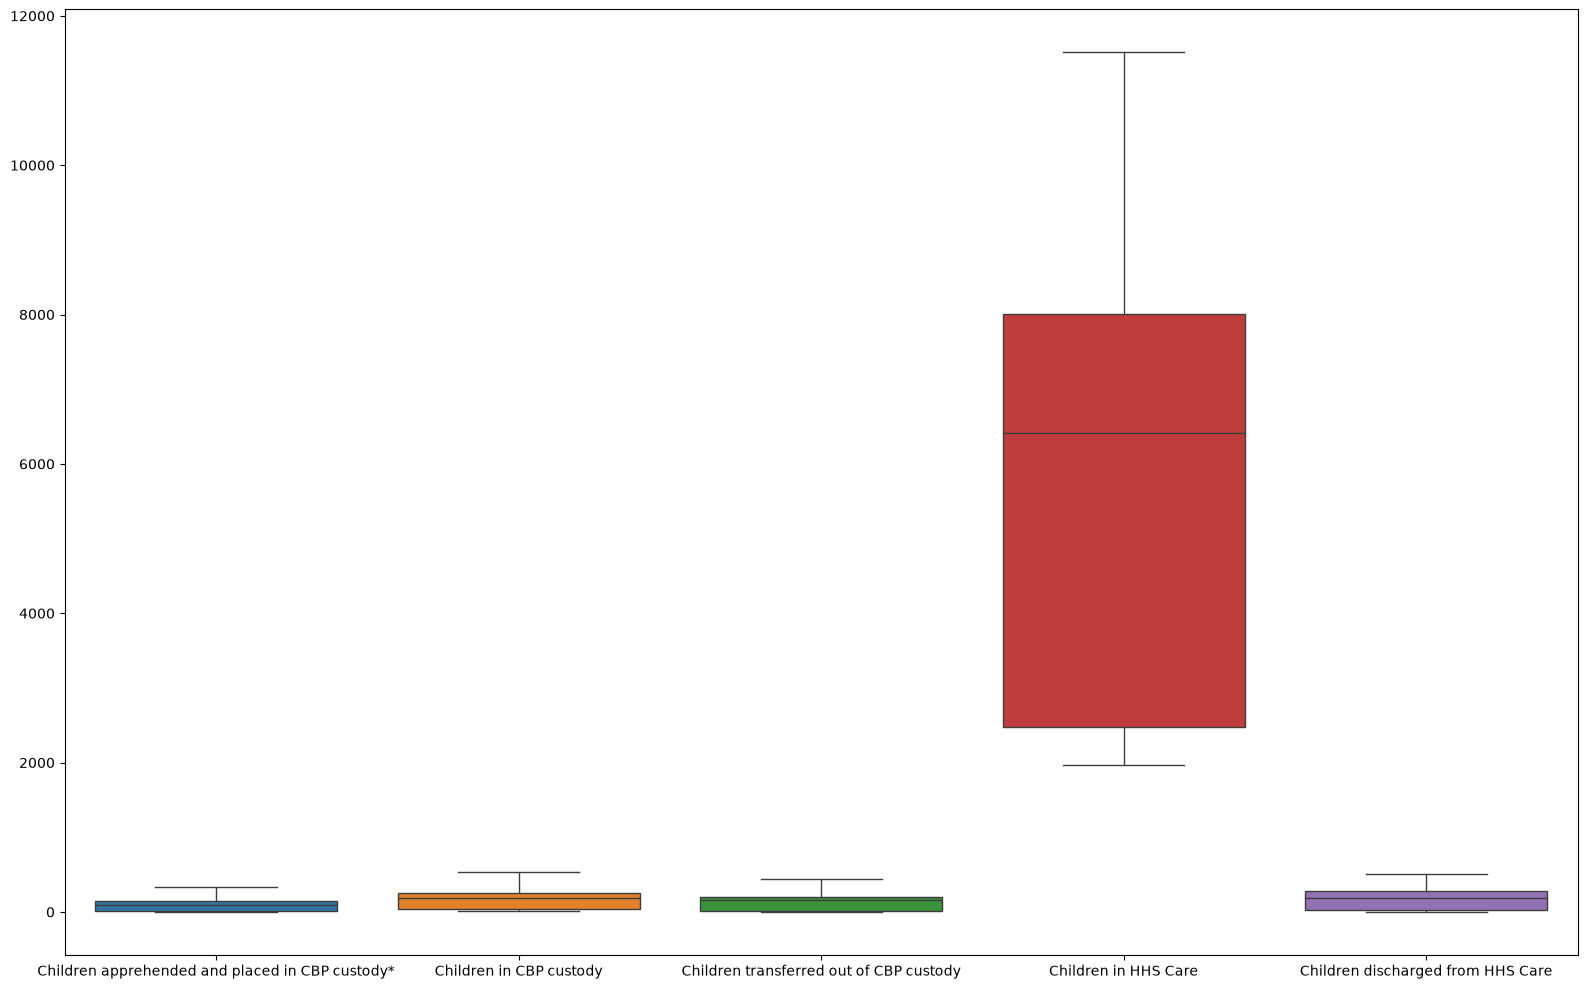

In [10]:
plt.figure(figsize=(16,10))
sns.boxplot(df[['Children apprehended and placed in CBP custody*','Children in CBP custody',
            'Children transferred out of CBP custody','Children in HHS Care',
            'Children discharged from HHS Care']])

plt.tight_layout()
plt.show()

In [11]:
def detect_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return series[(series < lower_bound) | (series > upper_bound)]
outliers = {}
for col in df.columns:
    outliers[col] = detect_outliers_iqr(df[col])
for col, vals in outliers.items():
    print(f"{col} -> {len(vals)} outliers")
    if not vals.empty:
        print(vals.values)


Children apprehended and placed in CBP custody* -> 0 outliers
Children in CBP custody -> 0 outliers
Children transferred out of CBP custody -> 0 outliers
Children in HHS Care -> 0 outliers
Children discharged from HHS Care -> 0 outliers


In [12]:
cols_to_check = ['Children apprehended and placed in CBP custody*',
                'Children transferred out of CBP custody','Children discharged from HHS Care']
zero_counts = (df[cols_to_check] == 0).sum()

print(zero_counts)

Children apprehended and placed in CBP custody*    2
Children transferred out of CBP custody            3
Children discharged from HHS Care                  1
dtype: int64


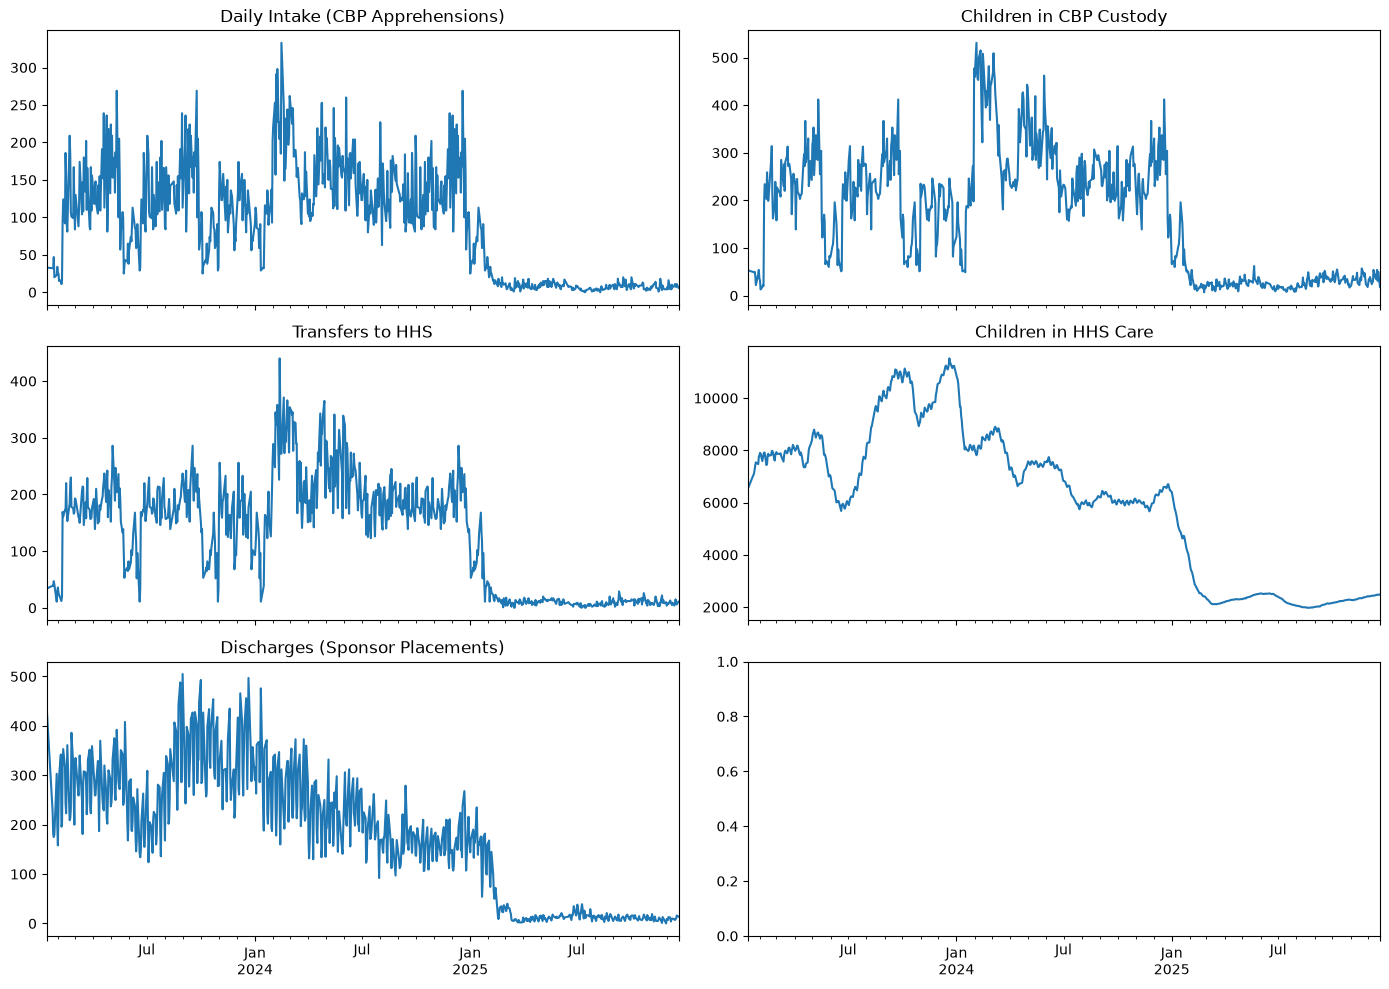

In [13]:
fig, axes = plt.subplots(3, 2, figsize=(14,10), sharex=True)

df['Children apprehended and placed in CBP custody*'].plot(ax=axes[0,0], title="Daily Intake (CBP Apprehensions)")
df['Children in CBP custody'].plot(ax=axes[0,1], title="Children in CBP Custody")
df['Children transferred out of CBP custody'].plot(ax=axes[1,0], title="Transfers to HHS")
df['Children in HHS Care'].plot(ax=axes[1,1], title="Children in HHS Care")
df['Children discharged from HHS Care'].plot(ax=axes[2,0], title="Discharges (Sponsor Placements)")

plt.tight_layout()
plt.show()

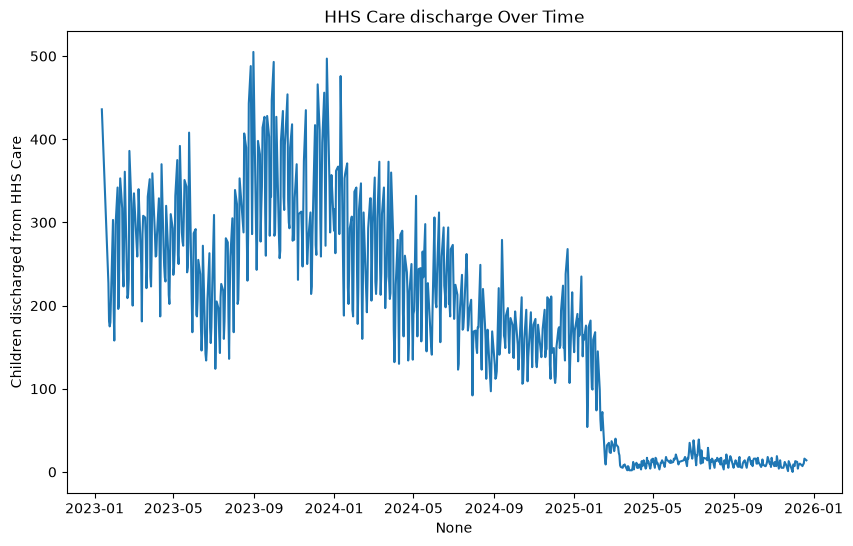

In [14]:
plt.figure(figsize=(10, 6))
sns.lineplot(x=df.index, y=df['Children discharged from HHS Care'])
plt.title('HHS Care discharge Over Time')
plt.show()

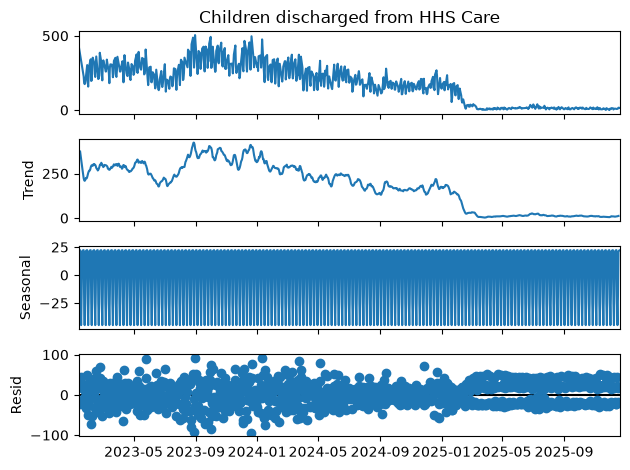

In [15]:
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(df['Children discharged from HHS Care'], model='additive',period=7)   # Seasonal Decomposition
result.plot()
plt.show()

In [16]:
from statsmodels.tsa.seasonal import seasonal_decompose
import numpy as np

def add_seasonal_features(df, target_col="Children discharged from HHS Care", period=7):
    """
    Adds seasonal decomposition features (trend, seasonal, resid) to dataframe.
    """
    result = seasonal_decompose(df[target_col], model="additive", period=period)
    
    df[f"{target_col}_trend"] = result.trend
    df[f"{target_col}_seasonal"] = result.seasonal
    df[f"{target_col}_resid"] = result.resid
    
    # Fill NaNs from decomposition edges
    df = df.bfill().ffill()
    
    return df

# Apply to discharge pipeline
df = add_seasonal_features(df, target_col="Children discharged from HHS Care", period=7)

# Fourier seasonal features (optional, smoother cycles)
def add_fourier_terms(df, target_col="Children discharged from HHS Care", K=3, period=7):
    """
    Adds Fourier seasonal terms for ML models.
    """
    t = np.arange(len(df))
    for k in range(1, K+1):
        df[f"sin_{k}"] = np.sin(2 * np.pi * k * t / period)
        df[f"cos_{k}"] = np.cos(2 * np.pi * k * t / period)
    return df

df = add_fourier_terms(df, target_col="Children discharged from HHS Care", K=3, period=7)


In [17]:
df.isnull().sum()

Children apprehended and placed in CBP custody*    0
Children in CBP custody                            0
Children transferred out of CBP custody            0
Children in HHS Care                               0
Children discharged from HHS Care                  0
Children discharged from HHS Care_trend            0
Children discharged from HHS Care_seasonal         0
Children discharged from HHS Care_resid            0
sin_1                                              0
cos_1                                              0
sin_2                                              0
cos_2                                              0
sin_3                                              0
cos_3                                              0
dtype: int64

In [18]:
# Example: include seasonal/trend features
feature_cols = [col for col in df.columns if col not in ["Children discharged from HHS Care"]]
X = df[feature_cols]
y = df["Children discharged from HHS Care"]
#horizon = 14

# Combine target and features first
df_model = pd.concat([y, X], axis=1)

# Drop rows with any NaNs or infs
df_model = df_model.replace([np.inf, -np.inf], np.nan).dropna()

# Redefine clean X and y
X_clean = df_model.drop(columns=["Children discharged from HHS Care"])
y_clean = df_model["Children discharged from HHS Care"]

# Train/test split AFTER cleaning
split_index = int(len(df_model) * 0.8)
X_train, X_test = X_clean.iloc[:split_index], X_clean.iloc[split_index:]
y_train, y_test = y_clean.iloc[:split_index], y_clean.iloc[split_index:]

In [24]:
# Drop rows with NaNs in exogenous features
X_train = X_train.dropna()
y_train = y_train.loc[X_train.index]  # align target with cleaned features

X_test = X_test.dropna()
y_test = y_test.loc[X_test.index]


In [33]:
X_train.shape,y_train.shape,X_test.shape,y_test.shape

((860, 13), (860,), (215, 13), (215,))

In [101]:
# SARIMAX with exogenous features
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
sarimax = SARIMAX(y_train, exog=X_train, order=(2,1,2), seasonal_order=(1,1,1,7))
sarimax_fit = sarimax.fit(maxiter=500,disp=False)

# ML models
xgb = XGBRegressor(learning_rate= 0.1, max_depth = 3, n_estimators = 500, subsample = 0.8)
xgb.fit(X_train, y_train)

gb = GradientBoostingRegressor(learning_rate=0.2,max_depth= 3,n_estimators=500, subsample=0.9)
gb.fit(X_train, y_train)
lr = LinearRegression()
lr.fit(X_train, y_train)

C:\Users\amar0\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[-0. , 0. ,-0. ,..., 0.04,-0.01, 0.09]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](13,)","['Children apprehended and placed in CBP custody*', 'Children in CBP custody','Children transferred out of CBP custody',..., 'cos_2','sin_3','cos_3']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.081
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,12


In [102]:
# SARIMAX forecast


# Pass only the first `horizon` rows of X_test
horizon = len(y_test)
sarimax_forecast = sarimax_fit.forecast(steps=horizon, exog=X_test[:horizon])



# ML forecasts
xgb_forecast = xgb.predict(X_test[:horizon])
gb_forecast = gb.predict(X_test[:horizon])
lr_forecast = lr.predict(X_test[:horizon])
hybrid_forecast = (sarimax_forecast + xgb_forecast) / 2


In [103]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_forecast(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    
    print(f"{model_name} -> MAE: {mae:.2f}, RMSE: {rmse:.2f}, R²: {r2:.2f}, MAPE: {mape:.2f}%")
evaluate_forecast(y_test, sarimax_forecast, "SARIMAX")
evaluate_forecast(y_test, xgb_forecast, "XGBoost")
evaluate_forecast(y_test, gb_forecast, "GradientBoosting")
evaluate_forecast(y_test, lr_forecast, "Linear Regression")
evaluate_forecast(y_test, hybrid_forecast, "Hybrid (SARIMAX+XGB)")


SARIMAX -> MAE: 1.04, RMSE: 1.16, R²: 0.96, MAPE: 11.83%
XGBoost -> MAE: 1.80, RMSE: 2.35, R²: 0.85, MAPE: 15.55%
GradientBoosting -> MAE: 2.01, RMSE: 2.84, R²: 0.78, MAPE: 17.45%
Linear Regression -> MAE: 0.40, RMSE: 0.53, R²: 0.99, MAPE: 3.68%
Hybrid (SARIMAX+XGB) -> MAE: 1.10, RMSE: 1.36, R²: 0.95, MAPE: 9.04%


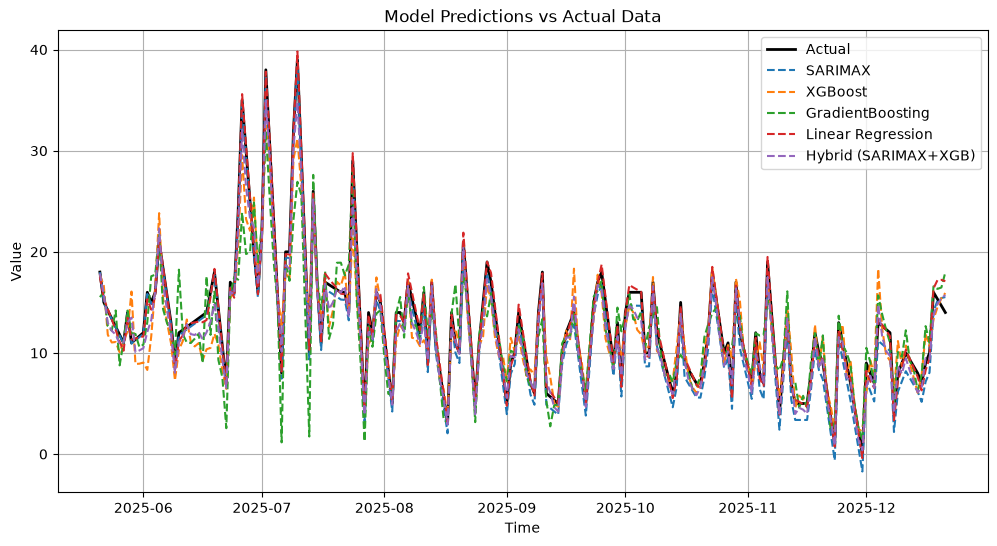

In [138]:
import matplotlib.pyplot as plt
xgb_forecast = pd.Series(xgb_forecast, index=y_test.index)
gb_forecast = pd.Series(gb_forecast, index=y_test.index)
lr_forecast = pd.Series(lr_forecast, index=y_test.index)
sarimax_forecast = pd.Series(sarimax_forecast, index=y_test.index)
hybrid_forecast = pd.Series(hybrid_forecast, index=y_test.index)
# Assume you have:
# y_test = actual values
# preds_sarimax, preds_xgb, preds_gb, preds_lr, preds_hybrid = model predictions

plt.figure(figsize=(12,6))

# Plot actual data
plt.plot(y_test, label='Actual', color='black', linewidth=2)

# Plot each model’s predictions
plt.plot(sarimax_forecast, label='SARIMAX', linestyle='--')
plt.plot(xgb_forecast, label='XGBoost', linestyle='--')
plt.plot(gb_forecast, label='GradientBoosting', linestyle='--')
plt.plot(lr_forecast, label='Linear Regression', linestyle='--')
plt.plot(hybrid_forecast, label='Hybrid (SARIMAX+XGB)', linestyle='--')

# Formatting
plt.title("Model Predictions vs Actual Data")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()